Peligros Hidrometeorológicos 2025-1 <p>
**Taller en Python - Proyecciones de cambio climático**<p>
Pedro Rau, PhD - praul@uni.edu.pe

#1. Leyendo datos de Precipitación proyectada al año 2100 por un modelo de Circulación Global (GCM)
---





Leer el archivo texto "icmip5_pr_Amon_ACCESS1-0_rcp85_-77E_-12N_firstyear-lastyear_n_su_000.dat.txt" que contiene las precipitaciones proyectadas hasta el año 2100. Plotear toda la serie a escala mensual y estacional.

In [ ]:
# Lectura de archivo txt de modelo GCM y promedio mensual para rango de fechas
archivo = "/content/icmip5_pr_Amon_ACCESS1-0_rcp85_-77E_-12N_firstyear-lastyear_n_su_000.dat.txt" # Ingresar la ruta del archivo txt

In [ ]:
### NO EDITAR
## LIBRERIAS
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# LEER ARCHIVO IGNORANDO LA PARTE DE METADATOS
file_path = archivo
df = pd.read_csv(file_path, comment='#', delim_whitespace=True, header=None)
print(df.head())
# CAMBIANDO A NOMBRE 'year"
df.rename(columns={0: "year"}, inplace=True)
df.columns = ["year"] + list(range(1, 13))
df_melted = df.melt(id_vars=["year"], var_name="mes", value_name="pp") # CAMBIANDO FORMATTOS
df_melted = df_melted.sort_values(by=["year", "mes"]) # Orden POR ANIO Y MES
df_melted["fecha"] = pd.to_datetime(df_melted["year"].astype(str) + "-" + df_melted["mes"].astype(str), format="%Y-%m") # CREANDO COLUMNA PARA FECHA
df_final = df_melted[["fecha", "pp"]] # SELECCIONANDO COLUMNAS FINALES
# Mostrar resultado
print(df_final.head())
# FACTOR x30 (mensual)
df_final['pp'] = df_final['pp']*30

     0         1         2         3         4         5         6         7   \
0  1850  0.162440  0.119497  0.254030  0.287212  0.049977  0.022947  0.009652   
1  1851  0.141302  0.203754  0.257872  0.119576  0.104974  0.040597  0.033502   
2  1852  0.074264  0.273904  0.178458  0.076865  0.119779  0.020619  0.003280   
3  1853  0.149589  0.182532  0.151961  0.087080  0.078599  0.005470  0.106080   
4  1854  0.127567  0.070664  0.121563  0.216324  0.067512  0.072689  0.024423   

         8         9         10        11        12  
0  0.085294  0.064616  0.059547  0.101170  0.123622  
1  0.185988  0.059218  0.142087  0.068045  0.155051  
2  0.055750  0.050198  0.293176  0.266960  0.226278  
3  0.033371  0.095550  0.138493  0.088376  0.111384  
4  0.001104  0.083062  0.087909  0.030705  0.092157  


<ipython-input-4-2234b1388c8f>:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, comment='#', delim_whitespace=True, header=None)


          fecha        pp
0    1850-01-01  0.162440
251  1850-02-01  0.119497
502  1850-03-01  0.254030
753  1850-04-01  0.287212
1004 1850-05-01  0.049977


<ipython-input-6-ed1c8b30b865>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['pp'] = df_final['pp']*30


<Axes: xlabel='fecha'>

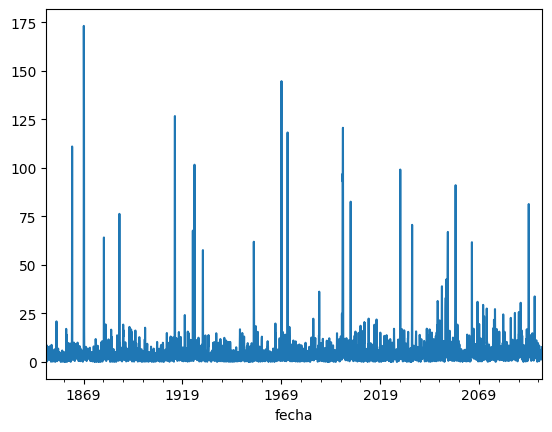

In [ ]:
df_final.index = df_final['fecha'] # INDEX fecha
df_final.pp.plot()

In [ ]:
# CALCULO PROMEDIO MENSUAL AGRUPANDO
df_mensual = df_final['pp'].groupby(df_final.index.month).mean()

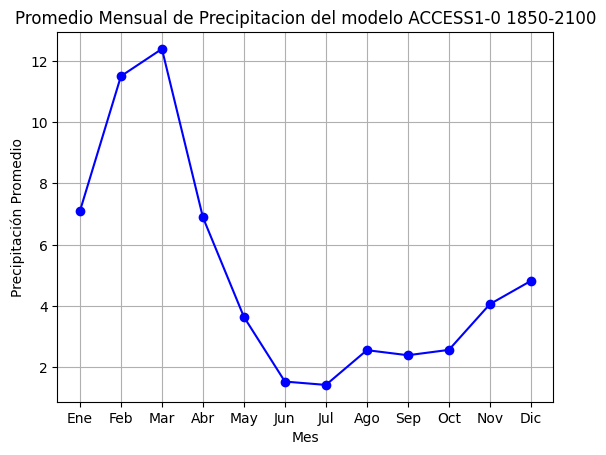

In [ ]:
# GRAFICO
df_mensual.plot(marker='o', linestyle='-', color='b')
plt.xlabel('Mes')
plt.ylabel('Precipitación Promedio')
plt.title('Promedio Mensual de Precipitacion del modelo ACCESS1-0 1850-2100')
plt.xticks(range(1, 13), ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
plt.grid()
plt.show()

#2. Analizando un periodo de años
---





Obtener el promedio mensual (tambien llamado análisis estacional) para el analisis de la precipitacion a mediano plazo (2050 al 2070).

In [ ]:
# Ingresar las fechas de inicio y fin para el analisis mensual promedio
fecha_inicio = '2050-01-01'  # indicar fecha inicial de analisis Ejm: 1 de enero del 2050
fecha_final = '2070-12-31' # indicar fecha final de analisis Ejm: 31 de diciembre del 2070

In [ ]:
### NO EDITAR
# CALCULO Y AGRUPAMIENTO
df_final_sel_years = df_final[(df_final.index >= fecha_inicio) & (df_final.index <= fecha_final)]
df_final_sel_years_group = df_final_sel_years['pp'].groupby(df_final_sel_years.index.month).mean()
# GRAFICO
df_final_sel_years_group.plot(marker='o', linestyle='-', color='b')
plt.xlabel('Mes')
plt.ylabel('Precipitación Promedio')
plt.title('Promedio Mensual de Precipitacion del modelo GCM')
plt.xticks(range(1, 13), ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
plt.grid()
plt.show()

In [ ]:
# EXPORTANDO SERIE DE TIEMPO
df_final_sel_years.to_csv('/content/drive/MyDrive/2025/SUPPORTS/CLIMATE_SERIES_TXT_31_03_2025/df_final_sel_years.csv', index=False)